In [1]:
import enum
import os
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as pads
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
fc_colors = np.array(
    [
        [64, 80, 160],
        [64, 96, 176],
        [96, 192, 240],
        [144, 208, 224],
        [255, 255, 255],
        [240, 240, 96],
        [240, 208, 64],
        [224, 112, 64],
        [224, 64, 48],
    ],
    dtype=np.uint8,
)

FC_CMAP = LinearSegmentedColormap.from_list("fc", fc_colors / 255.0)

In [4]:
project_root = Path(os.environ["PROJECT_ROOT"])

analyze_test_profile_dir = project_root / "results/analyze_test_profile_pyspi"
analyze_test_profile_dir.mkdir(exist_ok=True)

In [5]:
spi_list_dir = project_root / "resources/spi_lists"
set_cache_dir(spi_list_dir)

spi_config_map, _ = load_spi_config_map()

In [6]:
all_spis = (spi_list_dir / "spi_list_all_284.txt").read_text().strip().split()
print("\n".join(all_spis[:10]))

cov_EmpiricalCovariance
cov_EllipticEnvelope
cov_GraphicalLasso
cov_GraphicalLassoCV
cov_LedoitWolf
cov_MinCovDet
cov_OAS
cov_ShrunkCovariance
cov-sq_EmpiricalCovariance
cov-sq_EllipticEnvelope


In [7]:
spi_id_map = {spi: idx for idx, spi in enumerate(all_spis)}

In [8]:
spi_table = pd.DataFrame.from_records(
    [
        {"spi_id": idx, "spi": spi, **spi_config_map[spi]}
        for idx, spi in enumerate(all_spis)
    ]
)

spi_table.insert(
    2, "category", [module.split(".")[-1] for module in spi_table["module_name"]]
)
spi_table.insert(3, "identifier", [spi.split("_")[0] for spi in spi_table["spi"]])
spi_table = spi_table.drop(columns=["module_name"])

spi_table.head(4)

,spi_id,spi,category,identifier,fcn,params
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'}
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'}
2,2,cov_GraphicalLasso,basic,cov,Covariance,{'estimator': 'GraphicalLasso'}
3,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'}


In [9]:
(
    spi_table.groupby("category")
    .agg({"fcn": "nunique", "spi": "count"})
    .sort_values("spi", ascending=False)
)

,fcn,spi
category,,
spectral,17,114
infotheory,10,43
basic,5,42
distance,12,42
misc,4,24
causal,5,13
wavelet,1,6


We exclude squared SPIs which are easily derived from other SPIs.

In [10]:
distinct_spis = (spi_list_dir / "spi_list_distinct_255.txt").read_text().strip().split()
distinct_spis_set = set(distinct_spis)
print("\n".join(distinct_spis[:10]))

cov_EmpiricalCovariance
cov_EllipticEnvelope
cov_GraphicalLasso
cov_GraphicalLassoCV
cov_LedoitWolf
cov_MinCovDet
cov_OAS
cov_ShrunkCovariance
prec_EmpiricalCovariance
prec_EllipticEnvelope


## Filtering SPIs

Load the pyspi results computed for all distinct SPIs (excluding squared, see above) for four runs of one subject (181131).

Inclusion criteria are:

- Successful completion of all four runs.
- Run time less than a knee point cutoff.

Initialize inclusion codes.

In [11]:
class IncludeCode(enum.StrEnum):
    INCLUDE = "I"
    DUPLICATE = "D"
    ERROR = "E"
    TIME = "T"


spi_include_codes = {}
for spi in all_spis:
    if spi in distinct_spis_set:
        spi_include_codes[spi] = IncludeCode.INCLUDE
    else:
        spi_include_codes[spi] = IncludeCode.DUPLICATE

In [12]:
pd.Series(spi_include_codes).value_counts()

I    255
D     29
Name: count, dtype: int64

Load the table which includes all SPIs that ran to completion.

In [13]:
test_profile_data_dir = (
    project_root / "data/hcp_1200_rfmri_schaefer_pyspi_test_profile/parc-200__pool-3"
)

test_prof_df: pd.DataFrame = (
    pads.dataset(test_profile_data_dir, format="arrow").to_table().to_pandas()
)

# Join with spi table
test_prof_df = spi_table.merge(test_prof_df, how="right", on=["spi_id", "spi"])

print(test_prof_df.shape)
print(test_prof_df.dtypes)
test_prof_df.iloc[:4, :13]

(796, 15)
spi_id           int64
spi             object
category        object
identifier      object
fcn             object
params          object
sub_id           int32
sub             object
ses              uint8
run              uint8
success           bool
run_time       float32
peak_mem_mb    float32
err             object
mat             object
dtype: object


,spi_id,spi,category,identifier,fcn,params,sub_id,sub,ses,run,success,run_time,peak_mem_mb
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},0,181131,1,1,True,1.100949,1.232801
1,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},0,181131,1,2,True,0.016619,1.231199
2,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},0,181131,2,1,True,0.138883,1.231146
3,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},0,181131,2,2,True,0.018585,1.231123


Assume that any SPIs not in the table timed out in the SLURM job.

(Nb, good to check that none of the slurm jobs failed for any other reason.)

In [14]:
slurm_fail_spis = set(distinct_spis) - set(test_prof_df["spi"].unique())
print("Num missing SPIs due to slurm timeout:", len(slurm_fail_spis))

for spi in slurm_fail_spis:
    spi_include_codes[spi] = IncludeCode.TIME

Num missing SPIs due to slurm timeout: 56


Count number of successful completions per SPI.

In [15]:
spi_completion_counts = test_prof_df.groupby("spi").agg(
    {"spi": "count", "success": "sum"}
)

Get SPIs with errors

In [16]:
spi_completion_counts.query("success < 4")

,spi,success
spi,,
cov_GraphicalLasso,4,0
prec_GraphicalLasso,4,0
sgc_parametric_max_fs-1_fmin-0-25_fmax-0-5_order-None,4,0
sgc_parametric_max_fs-1_fmin-0_fmax-0-25_order-None,4,0
sgc_parametric_max_fs-1_fmin-1e-05_fmax-0-5_order-None,4,0
sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_order-None,4,0
sgc_parametric_mean_fs-1_fmin-0_fmax-0-25_order-None,4,0
sgc_parametric_mean_fs-1_fmin-0_fmax-0-5_order-None,4,0


- `GraphicalLasso` fails bc of bad default regularization strength. `GraphicalLassoCV` works fine though.

- `sgc` with order `None` fails with this error

  ```
  ValueError: Model estimation order did not converge at max_order = 50
  ```

  But variants of `sgc` with order not equal to None work fine.

So, we should be ok to exclude these. Their methods are still represented.

In [17]:
incomplete_spis = list(spi_completion_counts.query("success < 4").index)
for spi in incomplete_spis:
    spi_include_codes[spi] = IncludeCode.ERROR
    print(spi_id_map[spi], spi, "E")

2 cov_GraphicalLasso E
18 prec_GraphicalLasso E
247 sgc_parametric_max_fs-1_fmin-0-25_fmax-0-5_order-None E
246 sgc_parametric_max_fs-1_fmin-0_fmax-0-25_order-None E
245 sgc_parametric_max_fs-1_fmin-1e-05_fmax-0-5_order-None E
238 sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_order-None E
237 sgc_parametric_mean_fs-1_fmin-0_fmax-0-25_order-None E
236 sgc_parametric_mean_fs-1_fmin-0_fmax-0-5_order-None E


In [18]:
pd.Series(spi_include_codes).value_counts()

I    191
T     56
D     29
E      8
Name: count, dtype: int64

In [19]:
complete_spis_set = set(spi_completion_counts.query("success == 4").index)
complete_spis = [spi for spi in all_spis if spi in complete_spis_set]
complete_df = test_prof_df.loc[test_prof_df["spi"].isin(complete_spis_set)]
print("Num complete SPIs:", len(complete_spis))
print("Comlete df shape:", complete_df.shape)

Num complete SPIs: 191
Comlete df shape: (764, 15)


Final filter by run time.

In [20]:
run_time_mem_df = complete_df.groupby("spi").agg(
    {"spi": "count", "success": "sum", "run_time": "median", "peak_mem_mb": "median"}
)
run_time_mem_df = run_time_mem_df.loc[complete_spis]

run_time = run_time_mem_df["run_time"].values
mem = run_time_mem_df["peak_mem_mb"].values

run_time_mem_df.head()

,spi,success,run_time,peak_mem_mb
spi,,,,
cov_EmpiricalCovariance,4,4,0.078734,1.231173
cov_EllipticEnvelope,4,4,1.942391,21.551685
cov_GraphicalLassoCV,4,4,84.511047,31.582432
cov_LedoitWolf,4,4,0.192468,1.597397
cov_MinCovDet,4,4,1.537105,21.550919


In [21]:
# Find the "knee point" of sorted values, i.e. cutoff after which the values sharply increase.
def find_knee_point(
    values: np.ndarray,
    angle: float = 5 / 8 * np.pi,
    vmin: float | None = None,
    vmax: float | None = None,
) -> float:
    if vmin is None:
        vmin = values.min()
    if vmax is None:
        vmax = values.max()

    x = np.linspace(0, 1, len(values))
    y = np.clip((values - vmin) / (vmax - vmin), 0, 1)
    order = np.argsort(y)
    y = y[order]
    X = np.stack([x, y], axis=1)

    direction = np.array([np.cos(angle), np.sin(angle)])
    dot = X @ direction
    idx = np.argmin(dot)
    cutoff = values[order[idx]]
    return cutoff

In [22]:
# angle of normal vector to the knee point plane
# angle closer to 90 degrees detects an early knee point
# larger angle -> more sharp knee point.
angle_degrees = 120
run_time_cutoff = find_knee_point(
    run_time, angle=np.deg2rad(angle_degrees), vmin=0, vmax=60 * 60
)
# round up to nearest 5 minutes
run_time_cutoff = 5 * 60 * int(np.ceil(run_time_cutoff / 5 / 60))
include_spi_count = np.sum(run_time <= run_time_cutoff)
print(f"Cutoff: {run_time_cutoff:.0f}s, count: {include_spi_count}")

Cutoff: 300s, count: 149


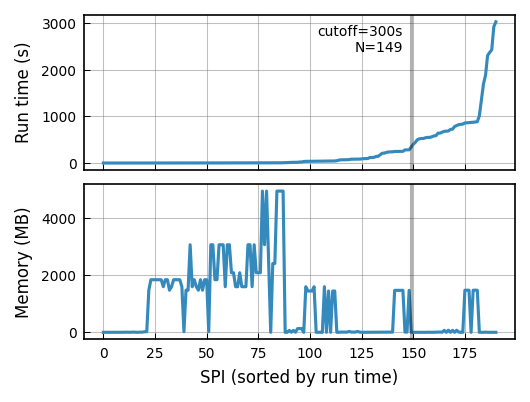

In [23]:
indices = np.argsort(run_time)

f, axs = plt.subplots(
    2,
    1,
    figsize=(1.0 * PLOTW, 0.75 * PLOTW),
    layout="constrained",
    sharex=True,
)

plt.sca(axs[0])
plt.plot(run_time[indices])
plt.axvline(include_spi_count, color="k", alpha=0.3, label=f"cutoff={run_time_cutoff}s")
ymin, ymax = plt.ylim()
plt.text(
    include_spi_count - 4,
    0.98 * (ymin + ymax),
    (f"cutoff={run_time_cutoff}s\nN={include_spi_count}"),
    ha="right",
    va="top",
    fontsize="small",
)
# plt.legend()
plt.ylabel("Run time (s)")

plt.sca(axs[1])
plt.plot(mem[indices])
plt.axvline(include_spi_count, color="k", alpha=0.3)
plt.xlabel("SPI (sorted by run time)")
plt.ylabel("Memory (MB)")

plt.savefig(analyze_test_profile_dir / f"pyspi_run_time_memory.{FORMAT}")

Estimate total run time for all SPIs and one run.

In [24]:
est_total_run_time = np.sum(run_time[run_time <= run_time_cutoff])
print(f"Est total run time: {est_total_run_time // 60:.0f} min")

Est total run time: 108 min


Save list of selected SPIs

In [25]:
include_spis_set = set(run_time_mem_df.loc[run_time <= run_time_cutoff].index.values)

# Keep original order
include_spis = [spi for spi in all_spis if spi in include_spis_set]

with (
    spi_list_dir / f"spi_list_select_{run_time_cutoff}s_{include_spi_count}.txt"
).open("w") as file:
    print("\n".join(include_spis), file=file)

Mark SPIs excluded by run time.

In [26]:
for spi in run_time_mem_df.loc[run_time > run_time_cutoff].index.values:
    spi_include_codes[spi] = IncludeCode.TIME

Final include/exclude counts

In [27]:
pd.Series(spi_include_codes).value_counts()

I    149
T     98
D     29
E      8
Name: count, dtype: int64

In [28]:
for spi in include_spis:
    print(spi, spi_include_codes[spi])

for spi, code in spi_include_codes.items():
    if code == "I" and spi not in include_spis_set:
        print(spi)

cov_EmpiricalCovariance I
cov_EllipticEnvelope I
cov_GraphicalLassoCV I
cov_LedoitWolf I
cov_MinCovDet I
cov_OAS I
cov_ShrunkCovariance I
prec_EmpiricalCovariance I
prec_EllipticEnvelope I
prec_GraphicalLassoCV I
prec_LedoitWolf I
prec_MinCovDet I
prec_OAS I
prec_ShrunkCovariance I
spearmanr I
kendalltau I
xcorr_max_sig-True I
xcorr_mean_sig-True I
xcorr_mean_sig-False I
pdist_euclidean I
pdist_cityblock I
pdist_cosine I
pdist_chebyshev I
pdist_canberra I
pdist_braycurtis I
dcorr I
dcorr_biased I
dtw I
dtw_constraint-sakoe-chiba I
lcss I
lcss_constraint-sakoe-chiba I
bary_euclidean_mean I
bary_euclidean_max I
gwtau I
reci I
je_gaussian I
je_kozachenko I
je_kernel_W-0.5 I
ce_gaussian I
ce_kernel_W-0.5 I
mi_gaussian I
mi_kernel_W-0.25 I
tlmi_gaussian I
tlmi_kraskov_NN-4 I
tlmi_kernel_W-0.25 I
te_kernel_W-0.25_k-1 I
gc_gaussian_k-1_kt-1_l-1_lt-1 I
te_symbolic_k-1_kt-1_l-1_lt-1 I
te_symbolic_k-10_kt-1_l-1_lt-1 I
phase_multitaper_mean_fs-1_fmin-0_fmax-0-5 I
phase_multitaper_mean_fs-1_fmin-0

Make a formatted table of all included SPIs, grouped by category and family identifier, including counts.

In [29]:
include_spi_table = spi_table.copy()
include_spi_table["include"] = include_spi_table["spi"].isin(include_spis_set)

include_spi_table = include_spi_table.rename(columns={"fcn": "function"})

In [30]:
include_spi_table.head(4)

,spi_id,spi,category,identifier,function,params,include
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},True
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'},True
2,2,cov_GraphicalLasso,basic,cov,Covariance,{'estimator': 'GraphicalLasso'},False
3,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'},True


In [31]:
include_category_spi_counts = (
    include_spi_table.groupby("category")
    .agg({"spi": "count", "include": "sum"})
    .rename(columns={"spi": "total"})
)

include_category_spi_counts

,total,include
category,,
basic,42,19
causal,13,1
distance,42,15
infotheory,43,14
misc,24,22
spectral,114,72
wavelet,6,6


In [32]:
include_category_id_counts_total = (
    include_spi_table.groupby("category")
    .agg({"identifier": "nunique"})
    .rename(columns={"identifier": "total"})
)

include_category_id_counts_include = (
    include_spi_table.query("include")
    .groupby("category")
    .agg({"identifier": "nunique"})
    .rename(columns={"identifier": "include"})
)

include_category_id_counts = pd.concat(
    [include_category_id_counts_total, include_category_id_counts_include],
    axis=1,
)

include_category_id_counts

,total,include
category,,
basic,10,5
causal,5,1
distance,13,6
infotheory,11,6
misc,4,3
spectral,17,12
wavelet,1,1


In [33]:
include_category_id_spis_counts = (
    include_spi_table.groupby(["category", "identifier"], sort=False)
    .agg({"spi_id": "count", "include": "sum", "spi": list})
    .rename(columns={"spi_id": "total"})
)

include_category_id_spis_counts.head(4)

total  include  \
category identifier                   
basic    cov             8        7   
         cov-sq          8        0   
         prec            8        7   
         prec-sq         8        0   

                                                                   spi  
category identifier                                                     
basic    cov         [cov_EmpiricalCovariance, cov_EllipticEnvelope...  
         cov-sq      [cov-sq_EmpiricalCovariance, cov-sq_EllipticEn...  
         prec        [prec_EmpiricalCovariance, prec_EllipticEnvelo...  
         prec-sq     [prec-sq_EmpiricalCovariance, prec-sq_Elliptic...

In [34]:
spi_indentifier_func_map = {
    identifier: func
    for identifier, func in zip(
        include_spi_table["identifier"], include_spi_table["function"]
    )
}

In [35]:
# Each spi on a new line, included shown in bold, excluded with exclusion code
def format_spis(spis: list[str]):
    spis_fmt = []
    for spi in spis:
        spi_fmt = f"({spi_id_map[spi] + 1:03d}) {spi}"
        if spi in include_spis_set:
            spi_fmt = f"<b>{spi_fmt}</b>"
        else:
            spi_fmt = f"{spi_fmt} ({spi_include_codes[spi].value})"
        spis_fmt.append(spi_fmt)
    return "<br>".join(spis_fmt)


# Add counts and short identifier names
def format_index(idx: tuple[str, str]):
    category, identifier = idx
    func = spi_indentifier_func_map[identifier]

    cat_spi_total, cat_spi_include = include_category_spi_counts.loc[
        category, ["total", "include"]
    ]
    cat_id_total, cat_id_include = include_category_id_counts.loc[
        category, ["total", "include"]
    ]
    id_spi_total, id_spi_include = include_category_id_spis_counts.loc[
        (category, identifier), ["total", "include"]
    ]

    category_fmt = (
        f"{category}<br>"
        f"({cat_id_include}/{cat_id_total} families)<br>"
        f"({cat_spi_include}/{cat_spi_total} SPIs)"
    )

    identifier_fmt = f"{identifier} ({func})<br>({id_spi_include}/{id_spi_total} SPIs)"
    return category_fmt, identifier_fmt


include_spi_table_fmt = include_category_id_spis_counts.copy()
include_spi_table_fmt = include_spi_table_fmt.drop(columns=["total", "include"])
include_spi_table_fmt["spi"] = include_spi_table_fmt["spi"].map(format_spis)
include_spi_table_fmt.index = include_spi_table_fmt.index.map(format_index)
include_spi_table_fmt.index.names = ["Category", "Family"]
include_spi_table_fmt.columns = ["SPIs"]

In [36]:
include_spi_table_fmt_style = include_spi_table_fmt.style.set_properties(
    **{"text-align": "left"}
).set_table_styles(
    [
        {"selector": "th", "props": [("text-align", "center")]},
        {
            "selector": ".row_heading",
            "props": [("text-align", "center"), ("vertical-align", "top")],
        },
    ]
)

include_spi_table_fmt_style

In [37]:
include_spi_table_fmt_style.to_html(analyze_test_profile_dir / "include_spi_table.html")

### Visualize example matrices for selected SPIs

In [38]:
# Number of ROIs
N_FEATURES = 200

In [39]:
def matshow(
    mat: np.ndarray,
    vmin: float | None = None,
    vmax: float | None = None,
    **kwargs,
):
    if vmax is None:
        vmax = np.max(np.abs(mat))
    if vmin is None:
        vmin = -vmax

    kwargs = {
        "cmap": FC_CMAP,
        "interpolation": "none",
        **kwargs,
    }
    plt.imshow(mat, vmin=vmin, vmax=vmax, **kwargs)
    plt.xticks([])
    plt.yticks([])

In [40]:
mat_df = (
    test_prof_df.loc[test_prof_df["spi"].isin(include_spis_set)]
    .query("ses == 1 and run == 1")
    .reset_index(drop=True)
)

print(mat_df.shape)
mat_df.iloc[:4, :10]

(149, 15)


,spi_id,spi,category,identifier,fcn,params,sub_id,sub,ses,run
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'},0,181131,1,1
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'},0,181131,1,1
2,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'},0,181131,1,1
3,4,cov_LedoitWolf,basic,cov,Covariance,{'estimator': 'LedoitWolf'},0,181131,1,1


In [41]:
# mapping of (category, identifier) -> row indices
row_lut = defaultdict(list)

for idx, row in mat_df.iterrows():
    row_lut[(row["category"], row["identifier"])].append(idx)

In [42]:
nrow = len(row_lut)
ncol = max(len(v) for v in row_lut.values())
print(nrow, ncol)

34 12


SPIs organized with each identifier family on another row.

In [43]:
def plot_example_matrices_by_family(category: str | None = None):
    if category is not None:
        cat_row_lut = {
            (cat, id): indices
            for (cat, id), indices in row_lut.items()
            if cat == category.lower()
        }
    else:
        cat_row_lut = row_lut

    plotw = 1.5
    ploth = 0.85 * plotw

    # wrap functions with lots of SPIs to max 7 cols
    ncol = 7
    wrap_cat_row_lut = {}
    for (cat, id), indices in cat_row_lut.items():
        for row_ind in range(int(np.ceil(len(indices) / ncol))):
            wrap_cat_row_lut[(cat, id, row_ind)] = indices[
                row_ind * ncol : (row_ind + 1) * ncol
            ]

    nrow = len(wrap_cat_row_lut)

    f, axs = plt.subplots(
        nrow,
        ncol,
        figsize=(ncol * plotw, nrow * ploth),
        layout="constrained",
        squeeze=False,
    )

    for ii, (cat, id, row_ind) in enumerate(wrap_cat_row_lut):
        if ii >= nrow:
            break

        indices = wrap_cat_row_lut[(cat, id, row_ind)]
        for jj in range(ncol):
            plt.sca(axs[ii, jj])
            if jj >= len(indices):
                plt.axis("off")
                continue

            idx = indices[jj]
            spi = mat_df.loc[idx, "spi"]
            mat = mat_df.loc[idx, "mat"]
            H = int(mat.size**0.5)
            mat = mat.reshape(H, H)

            vmax = max(np.nanquantile(np.abs(mat), 0.95), 1e-8)
            matshow(mat, vmax=vmax)
            cbar = plt.colorbar(fraction=0.05, pad=0.05)
            cbar.ax.tick_params(labelsize="xx-small")

            title = f"({spi_id_map[spi] + 1:03d}) {spi}"
            plt.title(title[:26], fontsize="x-small", pad=4)
            if jj == 0:
                ylabel = f"{cat} - {id}"
                if row_ind > 0:
                    ylabel = f"{ylabel} (cont)"
                plt.ylabel(ylabel, fontsize="small")

    return f

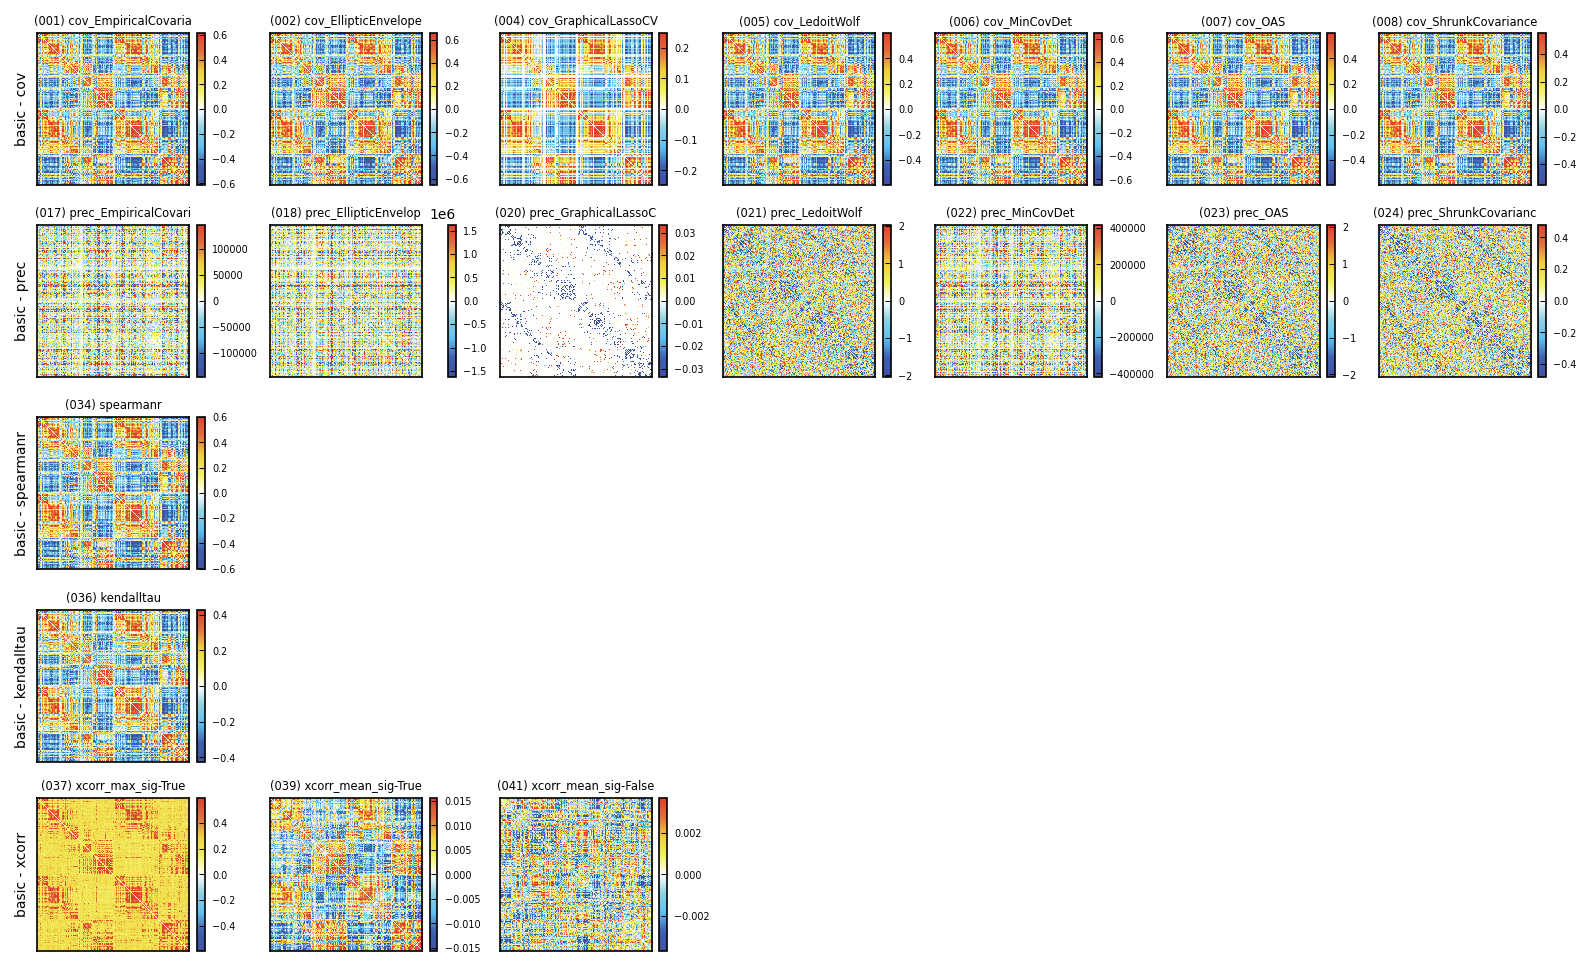

In [44]:
f = plot_example_matrices_by_family("basic")
f.show()

In [45]:
f = plot_example_matrices_by_family()
f.savefig(
    analyze_test_profile_dir / "example_spi_matrices_by_family.png",
    bbox_inches="tight",
)
plt.close(f)

In [46]:
def plot_example_matrices_flat(category: str | None = None):
    if category is not None:
        cat_mat_df = mat_df.query(f"category == '{category}'")
    else:
        cat_mat_df = mat_df

    plotw = 1.5
    ploth = 0.85 * plotw

    ncol = 10
    nrow = int(np.ceil(len(cat_mat_df) / ncol))

    f, axs = plt.subplots(
        nrow, ncol, figsize=(ncol * plotw, nrow * ploth), layout="constrained"
    )
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        plt.sca(ax)
        if ii >= len(cat_mat_df):
            plt.axis("off")
            continue

        cat = mat_df.loc[ii, "category"]
        spi = mat_df.loc[ii, "spi"]

        mat = mat_df.loc[ii, "mat"]
        H = int(mat.size**0.5)
        mat = mat.reshape(H, H)

        vmax = max(np.nanquantile(np.abs(mat), 0.95), 1e-8)
        matshow(mat, vmax=vmax)
        cbar = plt.colorbar(fraction=0.05, pad=0.05)
        cbar.ax.tick_params(labelsize="xx-small")

        title = f"({cat[0].upper()}) ({spi_id_map[spi] + 1:03d}) {spi}"
        plt.title(title[:26], fontsize="x-small", pad=4)

    return f

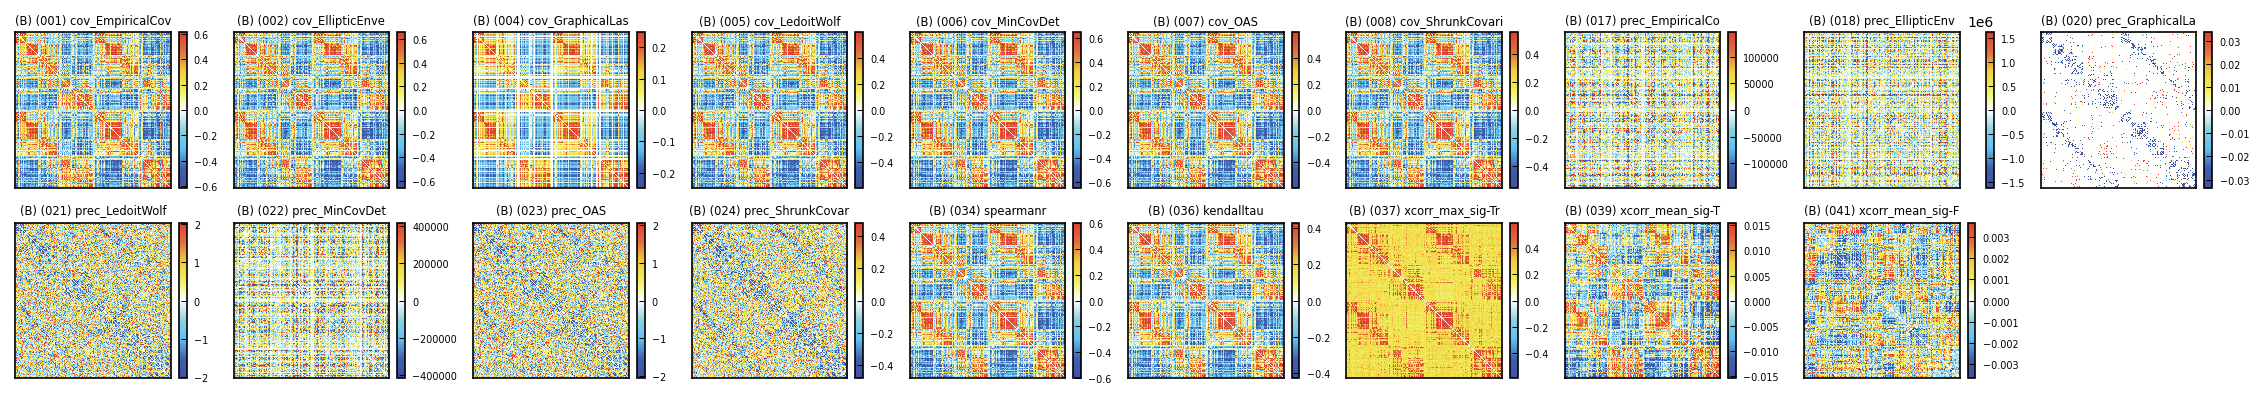

In [47]:
f = plot_example_matrices_flat("basic")
f.show()

In [48]:
f = plot_example_matrices_flat()
f.savefig(
    analyze_test_profile_dir / "example_spi_matrices_flat.png",
    bbox_inches="tight",
)
plt.close(f)